# Sales Data Analysis Using Python (Pandas)

### 🔹 Task 1: Data Loading & Basic Understanding


In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('Coffee.csv')

In [3]:
df.head(20)

,Area Code,Date,Market,Market Size,Product,Product Line,Product Type,State,Type,Budget COGS,Budget Margin,Budget Profit,Budget Sales,COGS,Inventory,Margin,Marketing,Profit,Sales,Total Expenses
0,719,40909,Central,Major Market,Amaretto,Beans,Coffee,Colorado,Regular,90,130,100,220,89,777,130,24,94,219,36
1,970,40909,Central,Major Market,Colombian,Beans,Coffee,Colorado,Regular,80,110,80,190,83,623,107,27,68,190,39
2,970,40909,Central,Major Market,Decaf Irish Cream,Beans,Coffee,Colorado,Decaf,100,140,110,240,95,821,139,26,101,234,38
3,303,40909,Central,Major Market,Green Tea,Leaves,Tea,Colorado,Regular,30,50,30,80,44,623,56,14,30,100,26
4,303,40909,Central,Major Market,Caffe Mocha,Beans,Espresso,Colorado,Regular,60,90,70,150,54,456,80,15,54,134,26
5,720,40909,Central,Major Market,Decaf Espresso,Beans,Espresso,Colorado,Decaf,80,130,80,210,72,558,108,23,53,180,55
6,970,40909,Central,Major Market,Chamomile,Leaves,Herbal Tea,Colorado,Decaf,140,160,110,300,170,1091,171,47,99,341,72
7,719,40909,Central,Major Market,Lemon,Leaves,Herbal Tea,Colorado,Decaf,50,80,20,130,63,435,87,57,0,150,87
8,970,40909,Central,Major Market,Mint,Leaves,Herbal Tea,Colorado,Decaf,50,70,40,120,60,336,80,19,33,140,47
9,719,40909,Central,Major Market,Darjeeling,Leaves,Tea,Colorado,Regular,40,70,20,110,58,338,72,22,17,130,55


In [4]:
df.shape



(4248, 20)

In [5]:
df.columns


Index(['Area Code', 'Date', 'Market', 'Market Size', 'Product', 'Product Line',
       'Product Type', 'State', 'Type', 'Budget COGS', 'Budget Margin',
       'Budget Profit', 'Budget Sales', 'COGS', 'Inventory', 'Margin',
       'Marketing', 'Profit', 'Sales', 'Total Expenses'],
      dtype='object')

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4248 entries, 0 to 4247
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Area Code       4248 non-null   int64 
 1   Date            4248 non-null   int64 
 2   Market          4248 non-null   object
 3   Market Size     4248 non-null   object
 4   Product         4248 non-null   object
 5   Product Line    4248 non-null   object
 6   Product Type    4248 non-null   object
 7   State           4248 non-null   object
 8   Type            4248 non-null   object
 9   Budget COGS     4248 non-null   int64 
 10  Budget Margin   4248 non-null   int64 
 11  Budget Profit   4248 non-null   int64 
 12  Budget Sales    4248 non-null   int64 
 13  COGS            4248 non-null   int64 
 14  Inventory       4248 non-null   int64 
 15  Margin          4248 non-null   int64 
 16  Marketing       4248 non-null   int64 
 17  Profit          4248 non-null   int64 
 18  Sales   

### 🔹 Task 2: Duplicate Records Handling

In [7]:
# Check duplicates
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

# Remove duplicates
df = df.drop_duplicates()

print("Updated Shape:", df.shape)


Duplicate Rows: 0
Updated Shape: (4248, 20)


### 🔹 Task 3: Missing Values Handling (Professional Method)


In [8]:
# Count missing values
df.isnull().sum()


Area Code         0
Date              0
Market            0
Market Size       0
Product           0
Product Line      0
Product Type      0
State             0
Type              0
Budget COGS       0
Budget Margin     0
Budget Profit     0
Budget Sales      0
COGS              0
Inventory         0
Margin            0
Marketing         0
Profit            0
Sales             0
Total Expenses    0
dtype: int64

##### Since there is no missing data so their is no need to perform further operations

### 🔹 Task 4: Remove Unnecessary Columns

In [9]:
df = df.drop(columns=['Area Code'])

df.columns


Index(['Date', 'Market', 'Market Size', 'Product', 'Product Line',
       'Product Type', 'State', 'Type', 'Budget COGS', 'Budget Margin',
       'Budget Profit', 'Budget Sales', 'COGS', 'Inventory', 'Margin',
       'Marketing', 'Profit', 'Sales', 'Total Expenses'],
      dtype='object')

### 🔹 Task 5: Data Discretization & Binning

In [10]:
# Create Sales Categories
bins = [df['Sales'].min(), 
        df['Sales'].quantile(0.33), 
        df['Sales'].quantile(0.66), 
        df['Sales'].max()]

labels = ['Low', 'Medium', 'High']

df['Sales_Category'] = pd.cut(df['Sales'], bins=bins, labels=labels, include_lowest=True)

df['Sales_Category'].value_counts()


Sales_Category
High      1443
Low       1409
Medium    1396
Name: count, dtype: int64

### 🔹 Task 6: Profit & Loss Analysis

#### A. Product Analysis

In [11]:
product_profit = df.groupby('Product')['Profit'].sum().sort_values(ascending=False)

product_profit
#sort function is not nesessary it is used to sort the values from highest to lowest just to make the data easy  to understand
#if incase anyone has to examine ranking of profitable products

Product
Colombian            55804
Lemon                29869
Decaf Espresso       29502
Darjeeling           29053
Chamomile            27231
Earl Grey            24164
Caffe Mocha          17678
Decaf Irish Cream    13989
Caffe Latte          11375
Regular Espresso     10065
Mint                  6154
Amaretto              4890
Green Tea             -231
Name: Profit, dtype: int64

##### Highest profitable product

In [12]:
product_profit.idxmax()


'Colombian'

##### Loss generating product

In [13]:
product_profit.idxmin()


'Green Tea'

#### B. Area / State Analysis


In [14]:
state_profit = df.groupby('State')['Profit'].sum().sort_values()


In [15]:
df[df['Profit'] < 0].sort_values(by='Profit').head()


,Date,Market,Market Size,Product,Product Line,Product Type,State,Type,Budget COGS,Budget Margin,Budget Profit,Budget Sales,COGS,Inventory,Margin,Marketing,Profit,Sales,Total Expenses,Sales_Category
3687,41518,West,Small Market,Green Tea,Leaves,Tea,Nevada,Regular,190,-190,-280,0,302,6413,-302,114,-638,20,147,Low
4218,41609,West,Small Market,Green Tea,Leaves,Tea,Nevada,Regular,210,-210,-320,0,294,8252,-294,111,-605,33,145,Low
3510,41487,West,Small Market,Green Tea,Leaves,Tea,Nevada,Regular,180,-180,-260,0,284,5807,-284,107,-558,21,131,Low
2274,41275,West,Small Market,Green Tea,Leaves,Tea,Nevada,Regular,160,-160,-240,0,245,1419,-245,93,-552,19,132,Low
2805,41365,West,Small Market,Green Tea,Leaves,Tea,Nevada,Regular,170,-170,-250,0,260,3049,-260,98,-542,28,131,Low


### 🔹 Task 7: Business Insights

Highest profitable product: Colombian tea is the highest profit making product and giving the greatest percentage in profit 

Loss making product: Green tea is the only loss making product and requires taste as well as cost or pricing review

Best performing market/State: California shows the highest overall profit and strong market performance

Highest loss state: New Mexico is contributing the higest losses and need a strategic attention

Recommendation:

             --Increase promotion and inventory focus on Colombian coffee to maximize profit.

             --Evaluate pricing or reduce production/marketing and other costs for Green Tea.

             --Investigate operational inefficiencies and causes of loss in New Mexico.

             --Optimize expenditure in low performing states.

             --Focus on expansion in high preforming states.

### 🔹 Task 8: Data Visualization

In [16]:
import matplotlib.pyplot as plt


#### 📈 Plot 1: Sales Trend Over Time

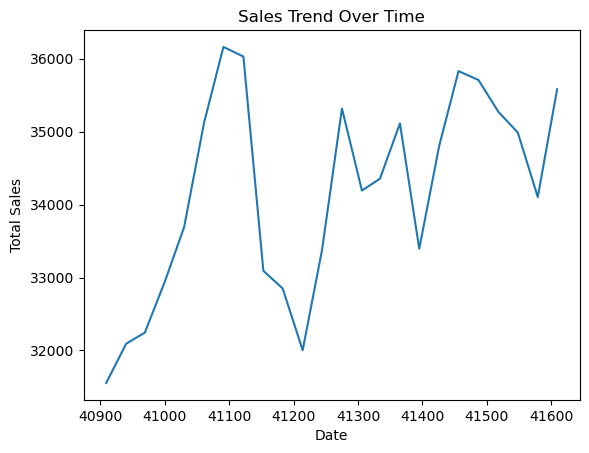

In [17]:
plt.figure()
df.groupby('Date')['Sales'].sum().plot()
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()


### 📊 Plot 2: Product Line Wise Total Sales

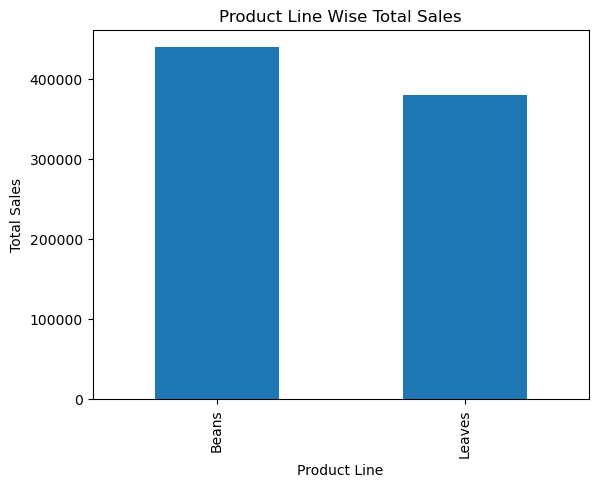

In [18]:
plt.figure()
df.groupby('Product Line')['Sales'].sum().plot(kind='bar')
plt.title("Product Line Wise Total Sales")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.show()


#### 📊 Plot 3: Market Size vs Sales

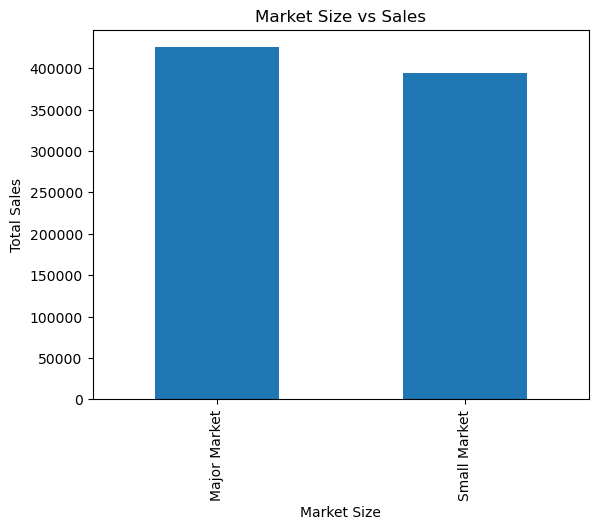

In [19]:
plt.figure()
df.groupby('Market Size')['Sales'].sum().plot(kind='bar')
plt.title("Market Size vs Sales")
plt.xlabel("Market Size")
plt.ylabel("Total Sales")
plt.show()


#### 📉 Plot 4: Sales vs Profit

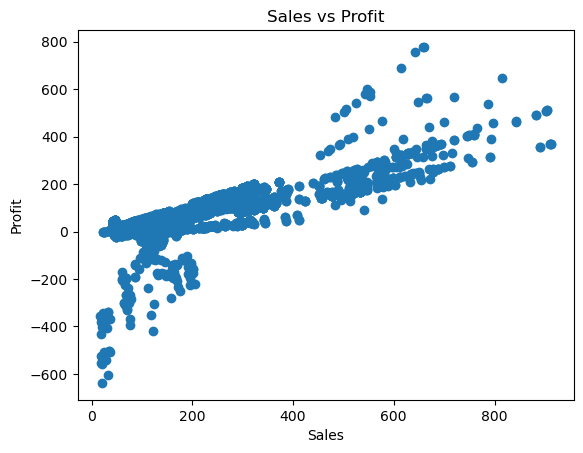

In [20]:
plt.figure()
plt.scatter(df['Sales'], df['Profit'])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()


#### 📊 Plot 5: State Wise Profit

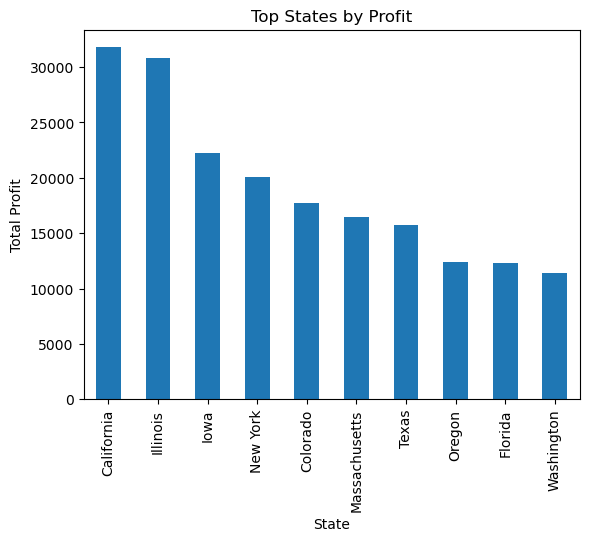

In [21]:
plt.figure()
df.groupby('State')['Profit'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top States by Profit")
plt.xlabel("State")
plt.ylabel("Total Profit")
plt.show()


#### 📉 Plot 6: Loss-Making Products

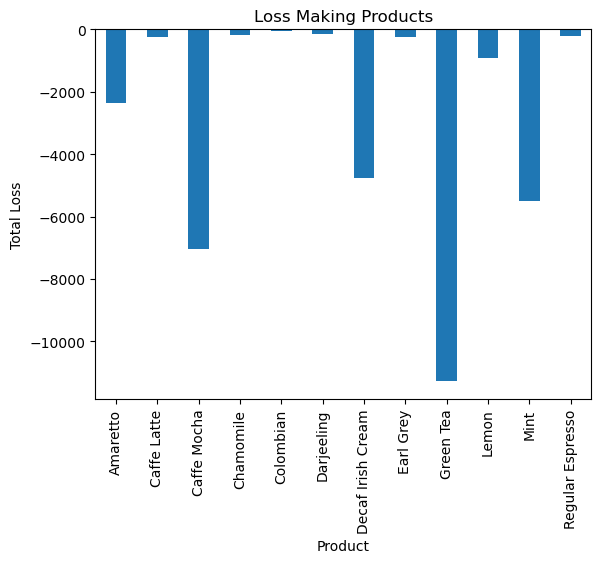

In [22]:
loss_df = df[df['Profit'] < 0]

plt.figure()
loss_df.groupby('Product')['Profit'].sum().plot(kind='bar')
plt.title("Loss Making Products")
plt.xlabel("Product")
plt.ylabel("Total Loss")
plt.show()


#### 📊 Plot 7: Coffee Products Profit Comparison

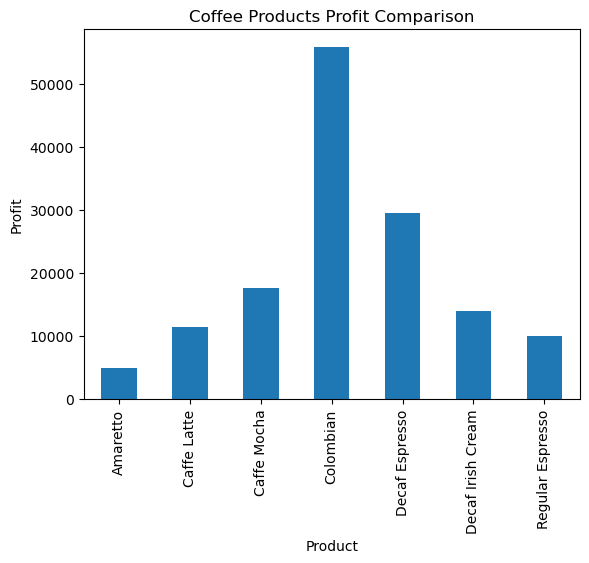

In [23]:
coffee_df = df[df['Product Line'] == 'Beans']   #in the Product line coffee product are named as beans
                                                #and Tea as leaves
plt.figure()
coffee_df.groupby('Product')['Profit'].sum().plot(kind='bar')
plt.title("Coffee Products Profit Comparison")
plt.xlabel("Product")
plt.ylabel("Profit")
plt.show()


#### 📦 Plot 8: Sales Distribution

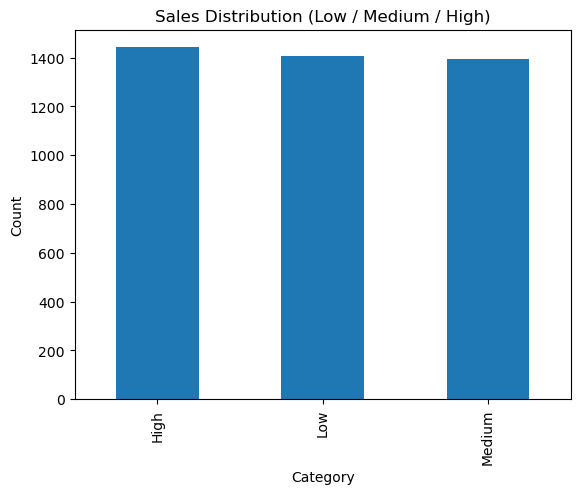

In [24]:
plt.figure()
df['Sales_Category'].value_counts().plot(kind='bar')
plt.title("Sales Distribution (Low / Medium / High)")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()


#### 📊 Plot 9: Marketing vs Profit

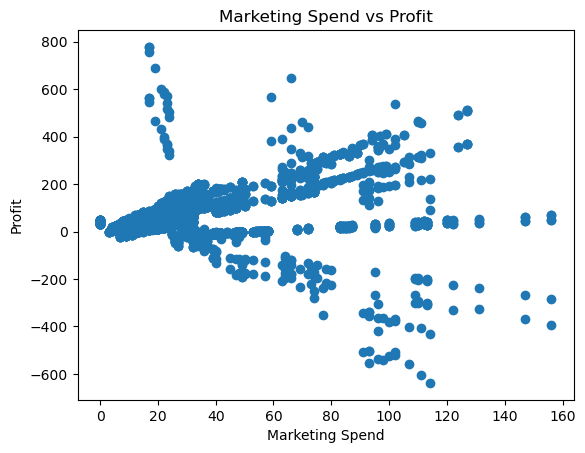

In [25]:
plt.figure()
plt.scatter(df['Marketing'], df['Profit'])
plt.title("Marketing Spend vs Profit")
plt.xlabel("Marketing Spend")
plt.ylabel("Profit")
plt.show()


In [26]:
df.to_csv("cleaned_sales_data.csv", index=False)
